In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"

#!rm -rf /home/ids/yuhe/.cache/torch_extensions


CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE/'
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()

print('Current working directory is:', '\n', notebook_path)

%load_ext autoreload
%autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code/diffusion-AE


In [2]:
import os
import h5py
import torch
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader

In [3]:
from templates import *
device = 'cuda:0'
conf = ffhq256_autoenc()
# print(conf.name)
model = LitModel(conf)
state = torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu')
model.load_state_dict(state['state_dict'], strict=False)
model.ema_model.eval()
model.ema_model.to(device)

Seed set to 0


Model params: 160.69 M


BeatGANsAutoencModel(
  (time_embed): TimeStyleSeperateEmbed(
    (time_embed): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
    (style): Identity()
  )
  (input_blocks): ModuleList(
    (0): TimestepEmbedSequential(
      (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1-2): 2 x TimestepEmbedSequential(
      (0): ResBlock(
        (in_layers): Sequential(
          (0): GroupNorm32(32, 128, eps=1e-05, affine=True)
          (1): SiLU()
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (h_upd): Identity()
        (x_upd): Identity()
        (emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=256, bias=True)
        )
        (cond_emb_layers): Sequential(
          (0): SiLU()
          (1): Linear(in_features=512, out_features=128, bias

In [4]:
# data = ImageDataset('imgs_align/test', image_size=conf.img_size, exts=['jpg', 'JPG', 'png'], do_augment=False)
# batch = data[0]['img'][None]

In [ ]:

# # Initialize dataset
# dataset = LatentDataset(
#     "datasets/encoded_latents_ffhq/encoded_ffhq_train_bg.h5",
#     "datasets/encoded_latents_ffhq/encoded_ffhq_train_glass.h5"
# )

# # DataLoader for training
# train_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize dataset
dataset = LatentDataset(
    "datasets/encoded_latents_ffhq/encoded_ffhq_test_bg.h5",
    "datasets/encoded_latents_ffhq/encoded_ffhq_test_glass.h5"
)

# DataLoader for training
train_dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [6]:
for batch in train_dataloader:  # Iterate over batches
    diffAE_Zbg = batch["diffAE_zbg"].to(device, non_blocking=True)
    diffAE_Zt = batch["diffAE_zt"].to(device, non_blocking=True)
    filename_bg = batch["filename_bg"]
    filename_t = batch["filename_t"]

    break

In [7]:
source ='t'
idx = 14

diff_Z = diffAE_Zt[idx]
filename = filename_t[idx]


In [8]:
filename

'24638.png'

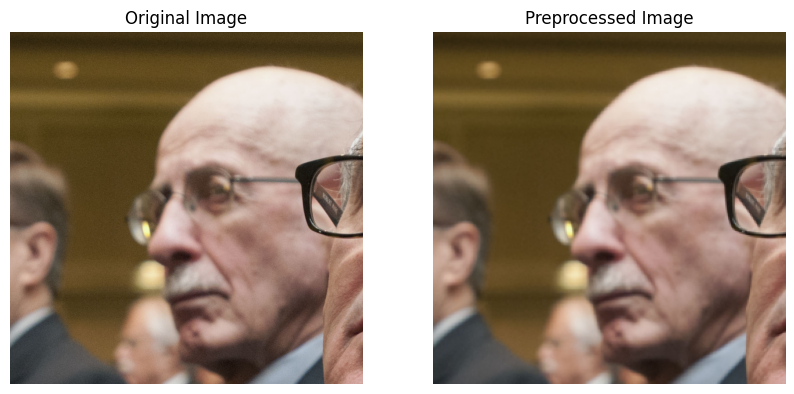

batch shape: torch.Size([1, 3, 256, 256])
diff_Z shape: torch.Size([512])


OutOfMemoryError: CUDA out of memory. Tried to allocate 4.00 GiB. GPU 0 has a total capacity of 39.50 GiB of which 949.81 MiB is free. Process 2360657 has 17.32 GiB memory in use. Including non-PyTorch memory, this process has 21.23 GiB memory in use. Of the allocated memory 16.81 GiB is allocated by PyTorch, and 3.91 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:

import torch
import matplotlib.pyplot as plt
from PIL import Image

if source =='bg':
    image_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_cs/train_bg/{filename}"
else:
    image_path = f"/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_cs/train_glass/{filename}"
# Load original image
original_img = Image.open(image_path)

dataset = SingleImageDataset(image_path, do_augment=False, image_size=256)
# Get preprocessed image from dataset
sample = dataset[0] 
batch = sample['img'][None]

# Plot both images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Show the original image
ax[0].imshow(original_img)
ax[0].set_title("Original Image")
ax[0].axis("off")

# Show the preprocessed image
ax[1].imshow(batch[0].permute(1, 2, 0) / 2 + 0.5)
ax[1].set_title("Preprocessed Image")
ax[1].axis("off")

plt.show()

print("batch shape:", batch.shape)
print("diff_Z shape:", diff_Z.shape)

diff_Z.unsqueeze(0) 
# Load original image

xT = model.encode_stochastic(batch.to(device), diff_Z, T=250)

# # Get preprocessed image from dataset
# sample = dataset[0] 
# batch = sample['img'][None]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ori = (batch + 1) / 2
ax[0].imshow(ori[0].permute(1, 2, 0).cpu())
ax[1].imshow(xT[0].permute(1, 2, 0).cpu())



# Encode

In [ ]:
pred = model.render(xT, diff_Z, T=100)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ori = (batch + 1) / 2
ax[0].imshow(ori[0].permute(1, 2, 0).cpu())
ax[1].imshow(pred[0].permute(1, 2, 0).cpu())

# Decode